In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

processed_dir = project_root / "data" / "processed"
results_root = project_root / "results"

import test01
importlib.reload(test01)

from test01 import (
    prepare_dataframes,
    build_preprocessor,
    compute_scale_pos_weight,
    build_xgb_pipeline,
    fit_model,
    evaluate_model,
    search_thresholds,
    compute_cost_table,
    evaluate_with_threshold,
    compute_expected_cost_from_cm,
    save_experiment_outputs,
    investigate_flagged_fraud,
)

print("Loaded functions from:", test01.__file__)

Loaded functions from: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\test01.py


In [2]:
paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test = pd.read_csv(processed_dir / "paysim_test.csv")

print("Train:", paysim_train.shape)
print("Validation:", paysim_val.shape)
print("Test:", paysim_test.shape)

Train: (4453834, 12)
Validation: (636262, 12)
Test: (1272524, 12)


The PaySim dataset contains an additional rule-based variable, isFlaggedFraud. Since this variable could potentially act as a shortcut for fraud prediction, it was investigated on the training split before model training. The analysis showed that only 14 out of 5,749 fraud cases were flagged, corresponding to a coverage of 0.24%. Although the precision of the flag was 100%, its extremely low coverage indicates that it does not capture the majority of fraudulent transactions. Therefore, the variable was not considered a meaningful leakage source and was retained as a weak rule-based signal.

In [3]:
from test01 import (
    prepare_dataframes,
    build_preprocessor,
    build_xgb_pipeline,
    fit_model,
    evaluate_model,
    investigate_flagged_fraud,
)

In [4]:
# ── Cell 1: Run the investigation on the training split ───────────────────────
#
# We always investigate on the raw train split so the numbers reflect what
# the model actually sees during training.  paysim_train here is the raw CSV
# DataFrame — NOT the output of prepare_dataframes().
 
flagged_report = investigate_flagged_fraud(paysim_train, split_name="train")
 
# ── Cell 2: Quick sanity check — type distribution of all fraud ───────────────
#
# isFlaggedFraud only fires on TRANSFER transactions in PaySim.
# This cross-tab shows whether fraud is concentrated in that type, which
# contextualises the coverage number above.
 
fraud_by_type = (
    paysim_train.groupby("type")["isFraud"]
    .agg(total="count", fraud_count="sum")
    .assign(fraud_rate=lambda x: (x["fraud_count"] / x["total"] * 100).round(3))
    .sort_values("fraud_count", ascending=False)
)
print("\nFraud distribution by transaction type (train):")
print(fraud_by_type.to_string())


=== isFlaggedFraud analysis — TRAIN ===
Total fraud cases       : 5,749
Flagged transactions    : 14
Flagged AND fraud       : 14
Coverage  (flag recall) : 0.24%  — flag catches this share of all fraud
Precision (flag)        : 100.00%  — share of flagged txns that are fraud
Verdict                 : LOW COVERAGE — not a meaningful shortcut. Safe to keep.

Type breakdown of flagged transactions:
  4             flagged=14  fraud=14  (100.0% fraud)

Fraud distribution by transaction type (train):
        total  fraud_count  fraud_rate
type                                  
1     1566250         2883       0.184
4      373140         2866       0.768
0      979357            0       0.000
2       29102            0       0.000
3     1505985            0       0.000


In [5]:
data = prepare_dataframes(
    paysim_train=paysim_train,
    paysim_val=paysim_val,
    paysim_test=paysim_test,
)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

numeric_features = data["numeric_features"]
categorical_features = data["categorical_features"]
feature_cols = data["feature_cols"]

print("Features used:")
print(feature_cols)

print("\nX_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

expected_engineered = [
    "balance_delta_orig",
    "balance_delta_dest",
    "amount_to_balance_ratio",
    "orig_balance_zeroed",
]

for col in expected_engineered:
    assert col in X_train.columns, f"Missing engineered feature: {col}"

print("\nFeature engineering is active.")

Features used:
['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'balance_delta_orig', 'balance_delta_dest', 'amount_to_balance_ratio', 'orig_balance_zeroed']

X_train shape: (4453834, 12)
X_val shape: (636262, 12)
X_test shape: (1272524, 12)

Feature engineering is active.


In [6]:
results_dir_none = results_root / "tabular_full_xgboost_none"
results_dir_none.mkdir(parents=True, exist_ok=True)

preprocessor_none = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)

model_none = build_xgb_pipeline(
    preprocessor=preprocessor_none,
    imbalance_method="none",
)

In [7]:
model_none = fit_model(
    model_none,
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    verbose=False,
)

print("Baseline XGBoost training finished.")

Early stopping: used 296 / 300 trees.
Baseline XGBoost training finished.


In [8]:
val_metrics_none, val_cm_none = evaluate_model(
    model_none,
    X_val,
    y_val,
    split_name="validation_none"
)

test_metrics_none, test_cm_none = evaluate_model(
    model_none,
    X_test,
    y_test,
    split_name="test_none"
)


=== VALIDATION_NONE ===
accuracy: 0.999852
precision: 0.952677
recall: 0.931790
f1: 0.942118
roc_auc: 0.999987
pr_auc: 0.990648

Confusion matrix:
[[635403     38]
 [    56    765]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999    635441
           1     0.9527    0.9318    0.9421       821

    accuracy                         0.9999    636262
   macro avg     0.9763    0.9659    0.9710    636262
weighted avg     0.9999    0.9999    0.9999    636262


=== TEST_NONE ===
accuracy: 0.999870
precision: 0.958437
recall: 0.940353
f1: 0.949309
roc_auc: 0.999565
pr_auc: 0.991117

Confusion matrix:
[[1270814      67]
 [     98    1545]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999   1270881
           1     0.9584    0.9404    0.9493      1643

    accuracy                         0.9999   1272524
   macro avg     0.9792    0.9702    0.9746

In [9]:
# ── Search thresholds on validation set ──────────────────────────────────────

threshold_results_none = search_thresholds(
    model_none,
    X_val,
    y_val
)

display(threshold_results_none)

,threshold,precision,recall,f1,predicted_fraud
0,0.10,0.829615,0.996346,0.905368,986
1,0.15,0.846154,0.991474,0.913068,962
2,0.20,0.874595,0.985384,0.926690,925
3,0.25,0.894327,0.979294,0.934884,899
4,0.30,0.909300,0.964677,0.936170,871
5,0.35,0.924528,0.954933,0.939485,848
6,0.40,0.934132,0.950061,0.942029,835
7,0.45,0.944988,0.941535,0.943258,818
8,0.50,0.952677,0.931790,0.942118,803
9,0.55,0.960759,0.924482,0.942272,790


In [10]:
# ── Compute expected cost for each threshold ─────────────────────────────────

cost_df_none = compute_cost_table(
    threshold_results_none,
    y_val
)

display(cost_df_none.head(10))

,threshold,tp,fp,fn,tn,precision,recall,f1,predicted_fraud,expected_cost
0,0.10,818,168,3,635273,0.829615,0.996346,0.905368,986,234000
1,0.15,814,148,7,635293,0.846154,0.991474,0.913068,962,424000
2,0.20,809,116,12,635325,0.874595,0.985384,0.926690,925,658000
3,0.25,804,95,17,635346,0.894327,0.979294,0.934884,899,897500
4,0.30,792,79,29,635362,0.909300,0.964677,0.936170,871,1489500
5,0.35,784,64,37,635377,0.924528,0.954933,0.939485,848,1882000
6,0.40,780,55,41,635386,0.934132,0.950061,0.942029,835,2077500
7,0.45,773,45,48,635396,0.944988,0.941535,0.943258,818,2422500
8,0.50,765,38,56,635403,0.952677,0.931790,0.942118,803,2819000
9,0.55,759,31,62,635410,0.960759,0.924482,0.942272,790,3115500


In [11]:
best_threshold_none = float(cost_df_none.iloc[0]["threshold"])

print("Best threshold for baseline XGBoost:", best_threshold_none)

Best threshold for baseline XGBoost: 0.1


In [12]:
# ── Final test evaluation using tuned threshold ──────────────────────────────

tuned_metrics_none, tuned_cm_none = evaluate_with_threshold(
    model_none,
    X_test,
    y_test,
    threshold=best_threshold_none
)


Tuned threshold: 0.1
Precision: 0.8430262480699948
Recall: 0.996956786366403
F1: 0.913552704963748

Confusion matrix:
[[1270576     305]
 [      5    1638]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9998    0.9999   1270881
           1     0.8430    0.9970    0.9136      1643

    accuracy                         0.9998   1272524
   macro avg     0.9215    0.9984    0.9567   1272524
weighted avg     0.9998    0.9998    0.9998   1272524



In [13]:
cost_summary_none = compute_expected_cost_from_cm(tuned_cm_none)

print("Expected cost on test set:")
print(cost_summary_none)

Expected cost on test set:
{'tp': 1638, 'fp': 305, 'fn': 5, 'tn': 1270576, 'expected_cost': 402500}


In [54]:
save_experiment_outputs(
    results_dir=results_dir_none,
    model=model_none,
    val_metrics=val_metrics_none,
    test_metrics=test_metrics_none,
    val_cm=val_cm_none,
    test_cm=test_cm_none,
    threshold_results=threshold_results_none,
    cost_df=cost_df_none,
    tuned_metrics=tuned_metrics_none,
    tuned_cm=tuned_cm_none,
    prefix="xgboost_none",
)

print("Saved outputs to:", results_dir_none)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_xgboost_none


# XGBoost with scale_pos_weight
This section trains an XGBoost model with imbalance correction through `scale_pos_weight`, evaluates it on the validation and test sets, tunes the classification threshold on the validation set, and computes expected fraud-detection cost.

In [15]:
scale_pos_weight = compute_scale_pos_weight(y_train)
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 773.7145590537485


## Build weighted XGBoost pipeline
The model uses the same train/validation/test split as previous experiments.
Imbalance is handled through the `scale_pos_weight` parameter.

In [16]:
results_dir_weighted = results_root / "tabular_full_xgboost_weighted"
results_dir_weighted.mkdir(parents=True, exist_ok=True)

preprocessor_weighted = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)

model_weighted = build_xgb_pipeline(
    preprocessor=preprocessor_weighted,
    imbalance_method="scale_pos_weight",
    scale_pos_weight=scale_pos_weight,
)


## Train the model
Fit the weighted XGBoost model on the full training split.

In [17]:
model_weighted = fit_model(
    model_weighted,
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    verbose=False,
)

print("Weighted XGBoost training finished.")

Early stopping: used 300 / 300 trees.
Weighted XGBoost training finished.


## Evaluate default threshold performance
First evaluate the model with the default classification threshold before threshold tuning.

In [18]:
val_metrics_weighted, val_cm_weighted = evaluate_model(
    model_weighted,
    X_val,
    y_val,
    split_name="validation_weighted",
)

test_metrics_weighted, test_cm_weighted = evaluate_model(
    model_weighted,
    X_test,
    y_test,
    split_name="test_weighted",
)


=== VALIDATION_WEIGHTED ===
accuracy: 0.999709
precision: 0.816733
recall: 0.998782
f1: 0.898630
roc_auc: 0.999986
pr_auc: 0.989167

Confusion matrix:
[[635257    184]
 [     1    820]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999    635441
           1     0.8167    0.9988    0.8986       821

    accuracy                         0.9997    636262
   macro avg     0.9084    0.9992    0.9492    636262
weighted avg     0.9998    0.9997    0.9997    636262


=== TEST_WEIGHTED ===
accuracy: 0.999723
precision: 0.824447
recall: 0.997565
f1: 0.902782
roc_auc: 0.999532
pr_auc: 0.989821

Confusion matrix:
[[1270532     349]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999   1270881
           1     0.8244    0.9976    0.9028      1643

    accuracy                         0.9997   1272524
   macro avg     0.9122    0.9986  

## Search thresholds on validation set
Predicted probabilities are converted into class predictions under different thresholds.
The goal is to find a threshold that reduces expected fraud-detection cost.

In [19]:
threshold_results_weighted = search_thresholds(
    model_weighted,
    X_val,
    y_val,
)

display(threshold_results_weighted)

,threshold,precision,recall,f1,predicted_fraud
0,0.10,0.778199,1.000000,0.875267,1055
1,0.15,0.790183,1.000000,0.882796,1039
2,0.20,0.798442,0.998782,0.887446,1027
3,0.25,0.801564,0.998782,0.889371,1023
4,0.30,0.803134,0.998782,0.890337,1021
5,0.35,0.808679,0.998782,0.893733,1014
6,0.40,0.809477,0.998782,0.894220,1013
7,0.45,0.812686,0.998782,0.896175,1009
8,0.50,0.816733,0.998782,0.898630,1004
9,0.55,0.820000,0.998782,0.900604,1000


## Compute expected cost by threshold
Expected cost is calculated using the predefined false-negative and false-positive costs.

In [20]:
cost_df_weighted = compute_cost_table(
    threshold_results_weighted,
    y_val,
)
display(cost_df_weighted.head(10))

,threshold,tp,fp,fn,tn,precision,recall,f1,predicted_fraud,expected_cost
0,0.15,821,218,0,635223,0.790183,1.000000,0.882796,1039,109000
1,0.10,821,234,0,635207,0.778199,1.000000,0.875267,1055,117000
2,0.85,820,175,1,635266,0.824121,0.998782,0.903084,995,137500
3,0.80,820,176,1,635265,0.823293,0.998782,0.902587,996,138000
4,0.75,820,177,1,635264,0.822467,0.998782,0.902090,997,138500
5,0.65,820,177,1,635264,0.822467,0.998782,0.902090,997,138500
6,0.70,820,177,1,635264,0.822467,0.998782,0.902090,997,138500
7,0.60,820,178,1,635263,0.821643,0.998782,0.901594,998,139000
8,0.55,820,180,1,635261,0.820000,0.998782,0.900604,1000,140000
9,0.50,820,184,1,635257,0.816733,0.998782,0.898630,1004,142000


## Select best threshold
The best threshold is chosen as the threshold with the lowest expected cost on the validation set.

In [21]:
best_threshold_weighted = float(cost_df_weighted.iloc[0]["threshold"])

print("Best threshold for weighted XGBoost:", best_threshold_weighted)

Best threshold for weighted XGBoost: 0.15000000000000002


## Evaluate tuned threshold on test set
The selected validation threshold is applied once to the held-out test set.

In [22]:
tuned_metrics_weighted, tuned_cm_weighted = evaluate_with_threshold(
    model_weighted,
    X_test,
    y_test,
    threshold=best_threshold_weighted,
)




Tuned threshold: 0.15000000000000002
Precision: 0.787223823246878
Recall: 0.9975654290931223
F1: 0.88

Confusion matrix:
[[1270438     443]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9998   1270881
           1     0.7872    0.9976    0.8800      1643

    accuracy                         0.9996   1272524
   macro avg     0.8936    0.9986    0.9399   1272524
weighted avg     0.9997    0.9996    0.9997   1272524



In [23]:
cost_summary_weighted = compute_expected_cost_from_cm(tuned_cm_weighted)

print("Expected cost on test set:")
print(cost_summary_weighted)


Expected cost on test set:
{'tp': 1639, 'fp': 443, 'fn': 4, 'tn': 1270438, 'expected_cost': 421500}


## Save experiment outputs
Save the trained model, metrics, confusion matrices, threshold search results, and tuned evaluation outputs.

In [52]:
save_experiment_outputs(
    results_dir=results_dir_weighted,
    model=model_weighted,
    val_metrics=val_metrics_weighted,
    test_metrics=test_metrics_weighted,
    val_cm=val_cm_weighted,
    test_cm=test_cm_weighted,
    threshold_results=threshold_results_weighted,
    cost_df=cost_df_weighted,
    tuned_metrics=tuned_metrics_weighted,
    tuned_cm=tuned_cm_weighted,
    prefix="xgboost_weighted",
)

print("Saved outputs to:", results_dir_weighted)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_xgboost_weighted


## Short interpretation
This experiment evaluates whether XGBoost with `scale_pos_weight` handles the extreme class imbalance better than the unweighted XGBoost model.
The final comparison will be made after running the SMOTE version as well.

# XGBoost with SMOTE
This section trains an XGBoost model with imbalance correction through SMOTE, evaluates it on the validation and test sets, tunes the classification threshold on the validation set, and computes expected fraud-detection cost.

In [25]:
results_dir_smote = results_root / "tabular_full_xgboost_smote_010"
results_dir_smote.mkdir(parents=True, exist_ok=True)

## Build XGBoost pipeline with SMOTE
The model uses the same train/validation/test split as previous experiments.
Imbalance is handled through SMOTE oversampling inside the training pipeline.

In [26]:
preprocessor_smote = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)

model_smote = build_xgb_pipeline(
    preprocessor=preprocessor_smote,
    imbalance_method="smote",
    smote_sampling_strategy=0.1,
)

model_smote

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'isFlaggedFraud',
                                                   'balance_delta_orig',
                                                   'balance_delta_dest',
                                                   'amount_to_balance_ratio',
                                                   'orig_balance_zeroed']),
                                                 ('cat',
                                                  Pipeline(steps=[...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Train the model
Fit the XGBoost + SMOTE model on the full training split.

In [27]:
model_smote = fit_model(
    model_smote,
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    verbose=False,
)

print("SMOTE XGBoost training finished.")

Early stopping: used 300 / 300 trees.
SMOTE XGBoost training finished.


## Evaluate default threshold performance
First evaluate the model with the default classification threshold before threshold tuning.

In [28]:
val_metrics_smote, val_cm_smote = evaluate_model(
    model_smote,
    X_val,
    y_val,
    split_name="validation_smote",
)

test_metrics_smote, test_cm_smote = evaluate_model(
    model_smote,
    X_test,
    y_test,
    split_name="test_smote",
)


=== VALIDATION_SMOTE ===
accuracy: 0.999976
precision: 0.982057
recall: 1.000000
f1: 0.990947
roc_auc: 1.000000
pr_auc: 1.000000

Confusion matrix:
[[635426     15]
 [     0    821]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    635441
           1     0.9821    1.0000    0.9909       821

    accuracy                         1.0000    636262
   macro avg     0.9910    1.0000    0.9955    636262
weighted avg     1.0000    1.0000    1.0000    636262


=== TEST_SMOTE ===
accuracy: 0.999976
precision: 0.983794
recall: 0.997565
f1: 0.990632
roc_auc: 0.999756
pr_auc: 0.998648

Confusion matrix:
[[1270854      27]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9838    0.9976    0.9906      1643

    accuracy                         1.0000   1272524
   macro avg     0.9919    0.9988    0.99

## Search thresholds on validation set
Predicted probabilities are converted into class predictions under different thresholds.
The goal is to find a threshold that reduces expected fraud-detection cost.

In [29]:
threshold_results_smote = search_thresholds(
    model_smote,
    X_val,
    y_val,
)

display(threshold_results_smote)

,threshold,precision,recall,f1,predicted_fraud
0,0.10,0.935080,1.0,0.966451,878
1,0.15,0.943678,1.0,0.971023,870
2,0.20,0.952436,1.0,0.975639,862
3,0.25,0.957993,1.0,0.978546,857
4,0.30,0.967020,1.0,0.983234,849
5,0.35,0.973903,1.0,0.986779,843
6,0.40,0.977381,1.0,0.988561,840
7,0.45,0.978546,1.0,0.989157,839
8,0.50,0.982057,1.0,0.990947,836
9,0.55,0.989157,1.0,0.994549,830


## Compute expected cost by threshold
Expected cost is calculated using the predefined false-negative and false-positive costs.

In [30]:
cost_df_smote = compute_cost_table(
    threshold_results_smote,
    y_val,
)

display(cost_df_smote.head(10))

,threshold,tp,fp,fn,tn,precision,recall,f1,predicted_fraud,expected_cost
0,0.95,821,0,0,635441,1.000000,1.0,1.000000,821,0
1,0.85,821,1,0,635440,0.998783,1.0,0.999391,822,500
2,0.80,821,1,0,635440,0.998783,1.0,0.999391,822,500
3,0.75,821,1,0,635440,0.998783,1.0,0.999391,822,500
4,0.90,821,1,0,635440,0.998783,1.0,0.999391,822,500
5,0.70,821,3,0,635438,0.996359,1.0,0.998176,824,1500
6,0.65,821,4,0,635437,0.995152,1.0,0.997570,825,2000
7,0.60,821,6,0,635435,0.992745,1.0,0.996359,827,3000
8,0.55,821,9,0,635432,0.989157,1.0,0.994549,830,4500
9,0.50,821,15,0,635426,0.982057,1.0,0.990947,836,7500


## Select best threshold
The best threshold is chosen as the threshold with the lowest expected cost on the validation set.

In [31]:
best_threshold_smote = float(cost_df_smote.iloc[0]["threshold"])

print("Best threshold for SMOTE XGBoost:", best_threshold_smote)

Best threshold for SMOTE XGBoost: 0.9500000000000003


## Evaluate tuned threshold on test set
The selected validation threshold is applied once to the held-out test set.

In [32]:
tuned_metrics_smote, tuned_cm_smote = evaluate_with_threshold(
    model_smote,
    X_test,
    y_test,
    threshold=best_threshold_smote,
)



Tuned threshold: 0.9500000000000003
Precision: 1.0
Recall: 0.9975654290931223
F1: 0.9987812309567337

Confusion matrix:
[[1270881       0]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     1.0000    0.9976    0.9988      1643

    accuracy                         1.0000   1272524
   macro avg     1.0000    0.9988    0.9994   1272524
weighted avg     1.0000    1.0000    1.0000   1272524



In [33]:
cost_summary_smote = compute_expected_cost_from_cm(tuned_cm_smote)

print("Expected cost on test set:")
print(cost_summary_smote)

Expected cost on test set:
{'tp': 1639, 'fp': 0, 'fn': 4, 'tn': 1270881, 'expected_cost': 200000}


## Save experiment outputs
Save the trained model, metrics, confusion matrices, threshold search results, and tuned evaluation outputs.


In [53]:
save_experiment_outputs(
    results_dir=results_dir_smote,
    model=model_smote,
    val_metrics=val_metrics_smote,
    test_metrics=test_metrics_smote,
    val_cm=val_cm_smote,
    test_cm=test_cm_smote,
    threshold_results=threshold_results_smote,
    cost_df=cost_df_smote,
    tuned_metrics=tuned_metrics_smote,
    tuned_cm=tuned_cm_smote,
    prefix="xgboost_smote_010",
)

print("Saved outputs to:", results_dir_smote)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_xgboost_smote_010


In [36]:
comparison_df = pd.DataFrame([
    {
        "model": "XGBoost none",
        "test_precision_0_5": test_metrics_none["precision"],
        "test_recall_0_5": test_metrics_none["recall"],
        "test_f1_0_5": test_metrics_none["f1"],
        "test_roc_auc": test_metrics_none["roc_auc"],
        "test_pr_auc": test_metrics_none["pr_auc"],
        "best_threshold": best_threshold_none,
        "tuned_precision": tuned_metrics_none["precision"],
        "tuned_recall": tuned_metrics_none["recall"],
        "tuned_f1": tuned_metrics_none["f1"],
        "tp": cost_summary_none["tp"],
        "fp": cost_summary_none["fp"],
        "fn": cost_summary_none["fn"],
        "tn": cost_summary_none["tn"],
        "expected_cost": cost_summary_none["expected_cost"],
    },
    {
        "model": "XGBoost weighted",
        "test_precision_0_5": test_metrics_weighted["precision"],
        "test_recall_0_5": test_metrics_weighted["recall"],
        "test_f1_0_5": test_metrics_weighted["f1"],
        "test_roc_auc": test_metrics_weighted["roc_auc"],
        "test_pr_auc": test_metrics_weighted["pr_auc"],
        "best_threshold": best_threshold_weighted,
        "tuned_precision": tuned_metrics_weighted["precision"],
        "tuned_recall": tuned_metrics_weighted["recall"],
        "tuned_f1": tuned_metrics_weighted["f1"],
        "tp": cost_summary_weighted["tp"],
        "fp": cost_summary_weighted["fp"],
        "fn": cost_summary_weighted["fn"],
        "tn": cost_summary_weighted["tn"],
        "expected_cost": cost_summary_weighted["expected_cost"],
    },
    {
        "model": "XGBoost SMOTE 0.1",
        "test_precision_0_5": test_metrics_smote["precision"],
        "test_recall_0_5": test_metrics_smote["recall"],
        "test_f1_0_5": test_metrics_smote["f1"],
        "test_roc_auc": test_metrics_smote["roc_auc"],
        "test_pr_auc": test_metrics_smote["pr_auc"],
        "best_threshold": best_threshold_smote,
        "tuned_precision": tuned_metrics_smote["precision"],
        "tuned_recall": tuned_metrics_smote["recall"],
        "tuned_f1": tuned_metrics_smote["f1"],
        "tp": cost_summary_smote["tp"],
        "fp": cost_summary_smote["fp"],
        "fn": cost_summary_smote["fn"],
        "tn": cost_summary_smote["tn"],
        "expected_cost": cost_summary_smote["expected_cost"],
    },
])

print(comparison_df)

comparison_path = results_root / "xgboost_full_model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Comparison table saved to:", comparison_path)

               model  test_precision_0_5  test_recall_0_5  test_f1_0_5  \
0       XGBoost none            0.958437         0.940353     0.949309   
1   XGBoost weighted            0.824447         0.997565     0.902782   
2  XGBoost SMOTE 0.1            0.983794         0.997565     0.990632   

   test_roc_auc  test_pr_auc  best_threshold  tuned_precision  tuned_recall  \
0      0.999565     0.991117            0.10         0.843026      0.996957   
1      0.999532     0.989821            0.15         0.787224      0.997565   
2      0.999756     0.998648            0.95         1.000000      0.997565   

   tuned_f1    tp   fp  fn       tn  expected_cost  
0  0.913553  1638  305   5  1270576         402500  
1  0.880000  1639  443   4  1270438         421500  
2  0.998781  1639    0   4  1270881         200000  
Comparison table saved to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgboost_full_model_comparison.csv


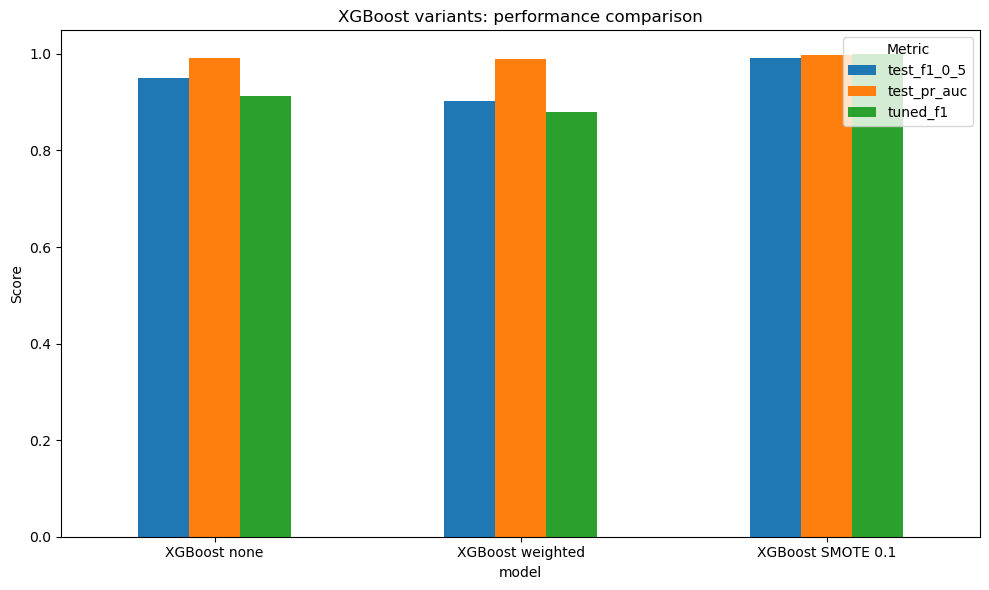

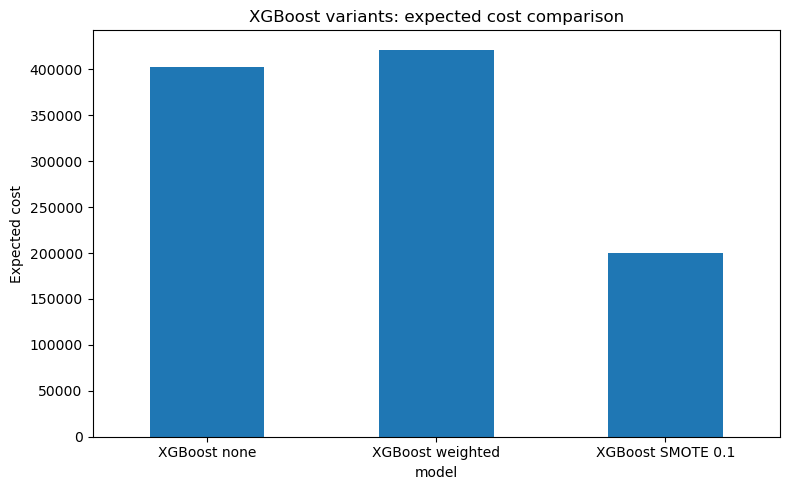

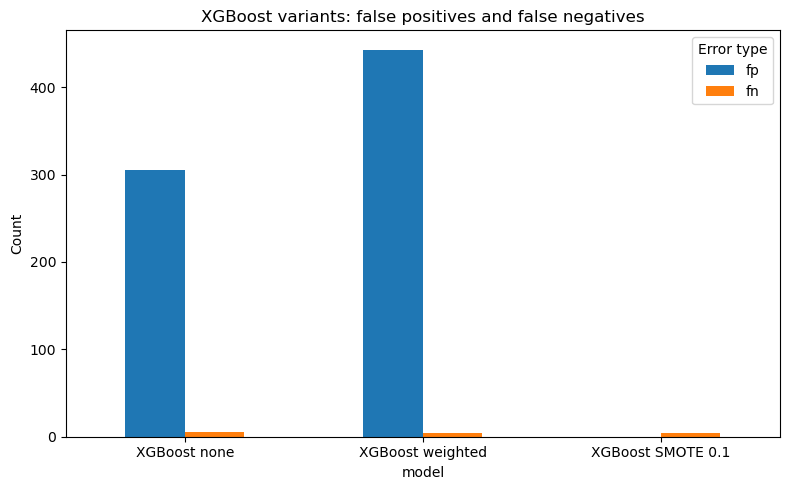

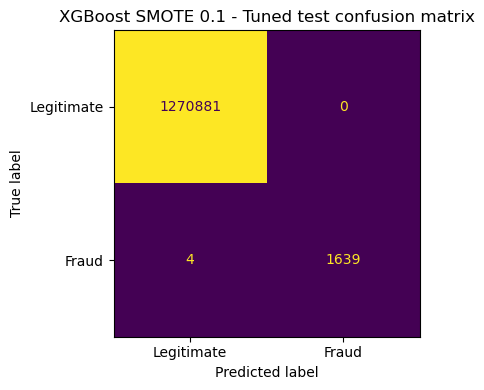

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Main performance comparison
plot_df = comparison_df.set_index("model")[[
    "test_f1_0_5",
    "test_pr_auc",
    "tuned_f1"
]]

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("XGBoost variants: performance comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


# 2. Expected cost comparison
cost_plot_df = comparison_df.set_index("model")[["expected_cost"]]

cost_plot_df.plot(kind="bar", figsize=(8, 5), legend=False)
plt.title("XGBoost variants: expected cost comparison")
plt.ylabel("Expected cost")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. False positives and false negatives
error_plot_df = comparison_df.set_index("model")[["fp", "fn"]]

error_plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("XGBoost variants: false positives and false negatives")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Error type")
plt.tight_layout()
plt.show()


# 4. Best model tuned confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm_smote,
    display_labels=["Legitimate", "Fraud"]
)
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("XGBoost SMOTE 0.1 - Tuned test confusion matrix")
plt.tight_layout()
plt.show()

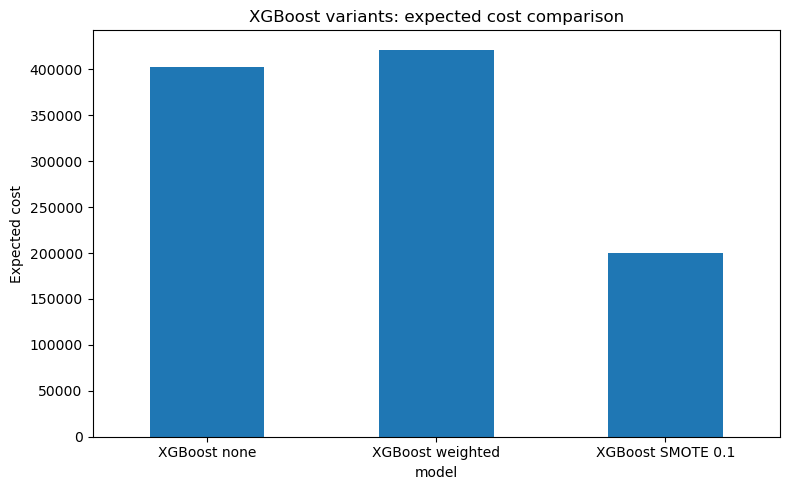

In [39]:
cost_plot_df = comparison_df.set_index("model")[["expected_cost"]]

cost_plot_df.plot(kind="bar", figsize=(8, 5), legend=False)

plt.title("XGBoost variants: expected cost comparison")
plt.ylabel("Expected cost")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

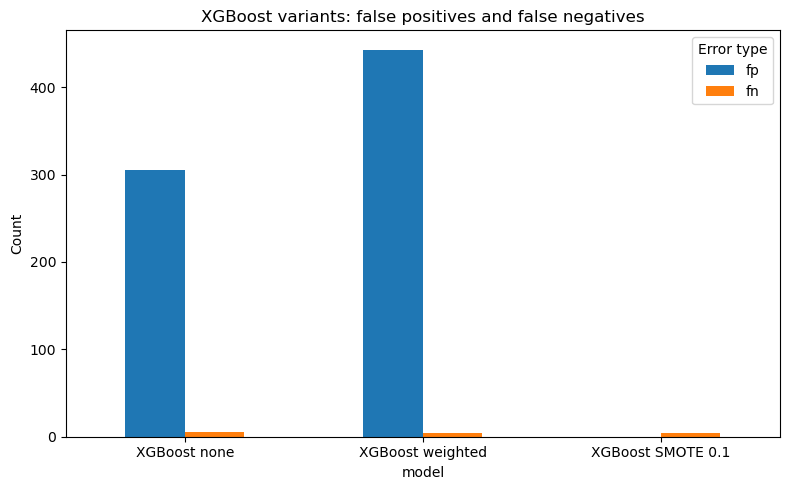

In [40]:
error_plot_df = comparison_df.set_index("model")[["fp", "fn"]]

error_plot_df.plot(kind="bar", figsize=(8, 5))

plt.title("XGBoost variants: false positives and false negatives")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Error type")
plt.tight_layout()
plt.show()

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [42]:
def plot_conf_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Fraud"]
    )
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

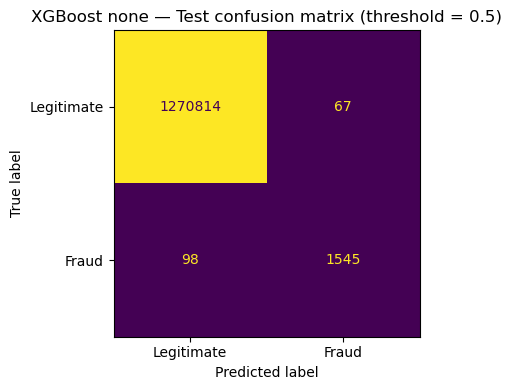

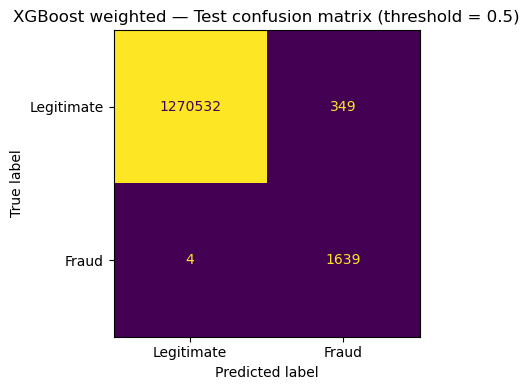

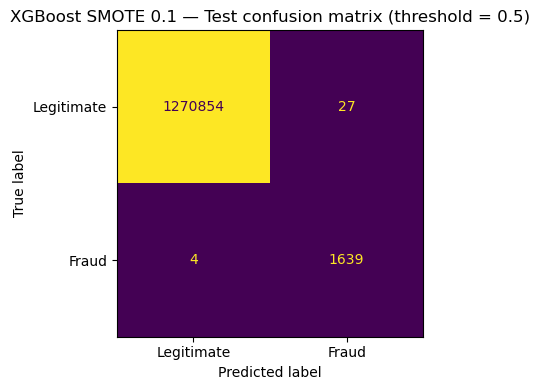

In [ ]:
plot_conf_matrix(test_cm_none, "XGBoost none — Test confusion matrix (threshold = 0.5)")
plot_conf_matrix(test_cm_weighted, "XGBoost weighted — Test confusion matrix (threshold = 0.5)")
plot_conf_matrix(test_cm_smote, "XGBoost SMOTE 0.1 — Test confusion matrix (threshold = 0.5)")

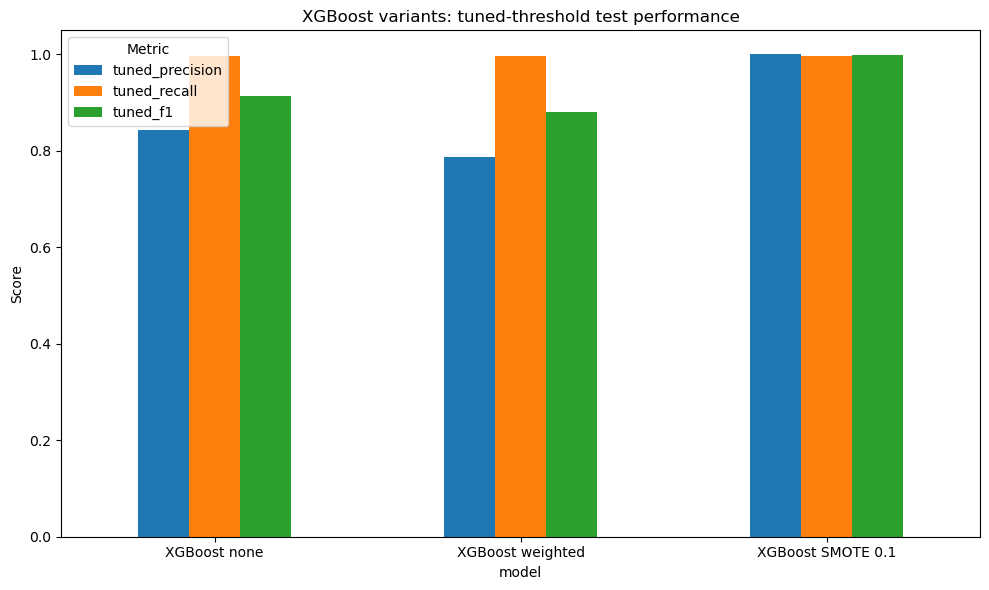

In [44]:
tuned_plot_df = comparison_df.set_index("model")[[
    "tuned_precision",
    "tuned_recall",
    "tuned_f1"
]]

tuned_plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("XGBoost variants: tuned-threshold test performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

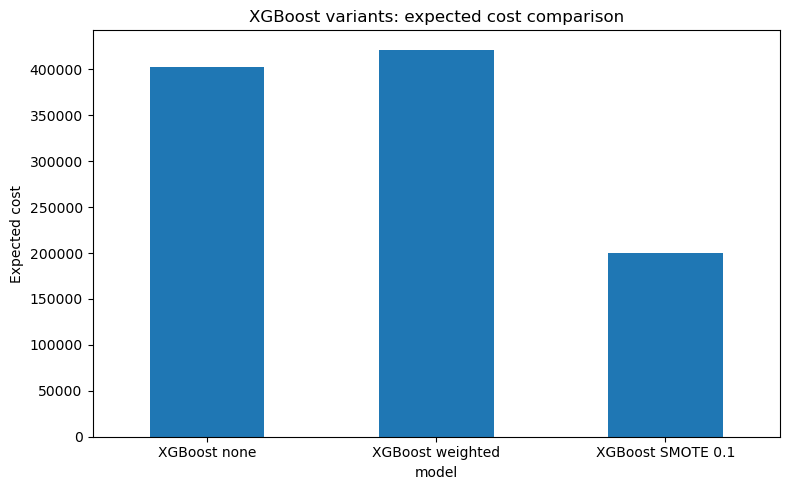

In [45]:
cost_plot_df = comparison_df.set_index("model")[["expected_cost"]]

cost_plot_df.plot(kind="bar", figsize=(8, 5), legend=False)

plt.title("XGBoost variants: expected cost comparison")
plt.ylabel("Expected cost")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

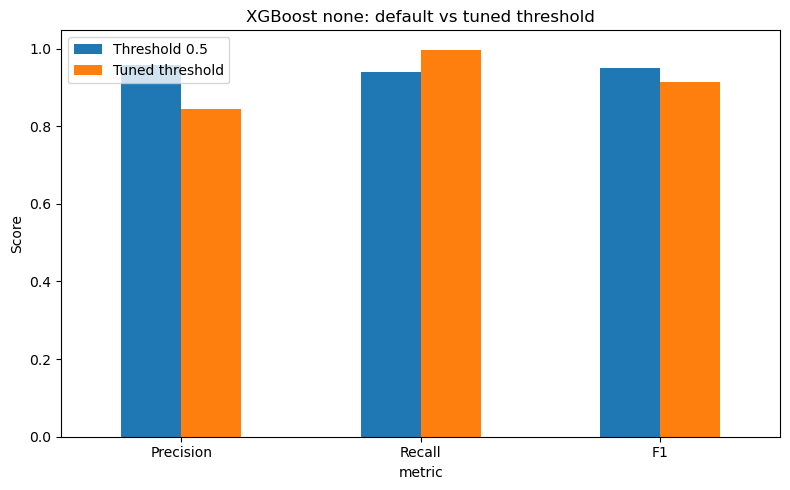

In [47]:
none_compare = pd.DataFrame({
    "metric": ["Precision", "Recall", "F1"],
    "Threshold 0.5": [
        test_metrics_none["precision"],
        test_metrics_none["recall"],
        test_metrics_none["f1"]
    ],
    "Tuned threshold": [
        tuned_metrics_none["precision"],
        tuned_metrics_none["recall"],
        tuned_metrics_none["f1"]
    ]
}).set_index("metric")

none_compare.plot(kind="bar", figsize=(8, 5))

plt.title("XGBoost none: default vs tuned threshold")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

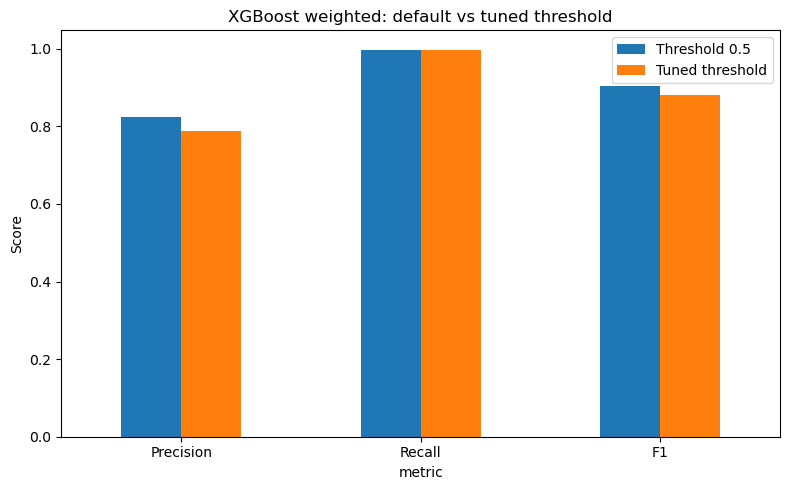

In [48]:
weighted_compare = pd.DataFrame({
    "metric": ["Precision", "Recall", "F1"],
    "Threshold 0.5": [
        test_metrics_weighted["precision"],
        test_metrics_weighted["recall"],
        test_metrics_weighted["f1"]
    ],
    "Tuned threshold": [
        tuned_metrics_weighted["precision"],
        tuned_metrics_weighted["recall"],
        tuned_metrics_weighted["f1"]
    ]
}).set_index("metric")

weighted_compare.plot(kind="bar", figsize=(8, 5))

plt.title("XGBoost weighted: default vs tuned threshold")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

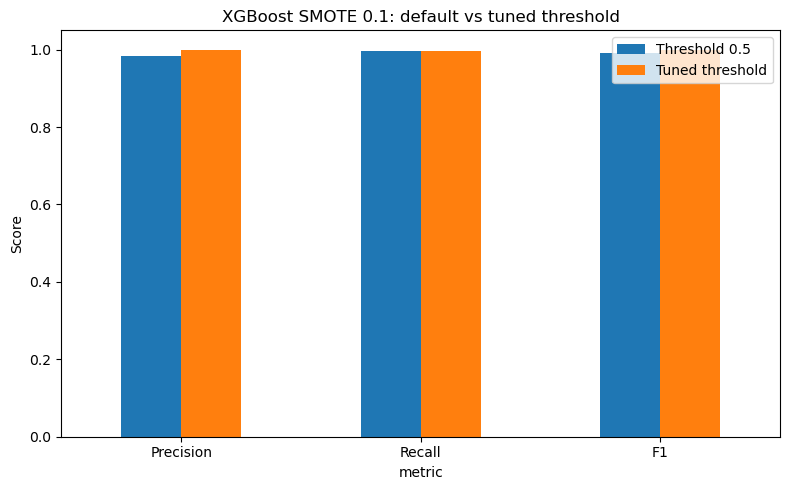

In [49]:
smote_compare = pd.DataFrame({
    "metric": ["Precision", "Recall", "F1"],
    "Threshold 0.5": [
        test_metrics_smote["precision"],
        test_metrics_smote["recall"],
        test_metrics_smote["f1"]
    ],
    "Tuned threshold": [
        tuned_metrics_smote["precision"],
        tuned_metrics_smote["recall"],
        tuned_metrics_smote["f1"]
    ]
}).set_index("metric")

smote_compare.plot(kind="bar", figsize=(8, 5))

plt.title("XGBoost SMOTE 0.1: default vs tuned threshold")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()